# Expert Regression Training – Step-by-Step Report

## Step 1: Objective

**Goal:**
Train expert regression models for each region, which predict **precise geographic coordinates** (latitude and longitude) from Street View images.
This is a **regression task** (not a classification task or director-based selection).

## Step 2: First Implementation – Cartesian Error

- **Initial approach:** We started with a simple regression model that minimized the distance between predicted and true coordinates in a **Cartesian coordinate system** (plain (x, y)).
- **Problem:**
  This method ignored the Earth's curvature, leading to incorrect loss calculations and meaningless geographic errors.



## Step 3: Error Realization and Loss Function Rework

- **Discovery:** After the first training runs, we observed absurdly high errors (e.g., median error over 9000 km for Japan/East Asia).
- **Conclusion:**
  The model was not learning; the Cartesian loss was not meaningful for global coordinates.
- **Action:**
  We rewrote the loss function to use the **Haversine distance**, which measures the shortest distance between two points on a sphere (the Earth).

## Step 4: Output Normalization and Clamping

- **Normalization:**
  We standardized the model outputs to the `[0, 1]` range. The network predicts normalized latitude and longitude, which are then denormalized back to real coordinates for evaluation.
- **Clamping:**
  We restricted model predictions so they cannot exceed the minimum and maximum latitude/longitude for each region. This prevents predictions that would be outside the valid region.

## Step 5: Loss Function Update – Squared Haversine

- **Enhancement:**
  The loss function was modified to minimize the **square of the Haversine distance**. This penalizes large errors more strongly and helps the model focus on reducing big mistakes.



## Step 6: First Results – High Errors

- After applying the above fixes, we retrained the models and evaluated them. Below are the results for selected regions:

| Region                        | Train (Mean/Median/90th P) | Val (Mean/Median/90th P) | Test (Mean/Median/90th P) |
|-------------------------------|----------------------------|--------------------------|---------------------------|
| North America (0)             | 681.44 / 588.25 / 1248.94  | 820.20 / 682.54 / 1552.47| 840.46 / 711.60 / 1548.36 |
| Latin America (1)             | 1337.68 / 1086.42 / 2660.42| 1782.96 / 1338.24 / 3831.67| 1713.24 / 1319.13 / 3696.15 |
| Western & Northern Europe (2) | 380.45 / 335.37 / 692.98   | 486.93 / 430.71 / 895.30 | 496.95 / 421.54 / 950.59  |
| Southern Europe (3)           | 541.40 / 476.23 / 1001.68  | 730.90 / 679.43 / 1332.91| 772.88 / 663.34 / 1468.50 |
| Eastern Europe & Balkans (4)  | 376.59 / 323.30 / 700.88   | 485.24 / 415.91 / 914.56 | 484.16 / 400.99 / 920.05  |
| Russia & Cyrillic (5)         | 953.31 / 802.70 / 1804.24  | 1233.11 / 993.59 / 2443.20| 1218.23 / 956.87 / 2426.12 |
| East Asia (6)                 | 487.57 / 419.35 / 899.41   | 664.63 / 533.05 / 1352.78| 683.98 / 570.47 / 1264.08 |
| Southeast Asia (7)            | 723.49 / 631.89 / 1383.06  | 915.47 / 816.90 / 1787.67| 909.94 / 786.42 / 1751.23 |
| South Asia (8)                | 433.49 / 372.09 / 832.65   | 527.13 / 455.26 / 999.37 | 542.26 / 443.65 / 1070.79 |
| Africa (9)                    | 674.42 / 495.73 / 1419.90  | 856.03 / 596.52 / 1928.76| 877.33 / 587.54 / 1943.49 |
| Arabia (10)                   | 467.49 / 373.91 / 932.49   | 535.69 / 385.19 / 1106.15| 577.46 / 431.78 / 1210.81 |
| Oceania (11)                  | 689.63 / 601.62 / 1271.26  | 851.34 / 703.08 / 1737.14| 859.68 / 693.95 / 1722.35 |
| Rare Regions (12)             | 153.21 / 93.69 / 319.10    | 175.74 / 88.00 / 291.43  | 138.10 / 81.28 / 319.24   |

*(All distances in km; columns are: Mean / Median / 90th Percentile)*

- **Observation:**
  Results were still unsatisfactory, especially for large or diverse regions (e.g., Russia, Latin America).


## Step 7: Further Improvements – Scheduler & Longer Training

- **Scheduler:**
  Introduced a learning rate scheduler to help with convergence.
- **Epochs:**
  Increased training to 20 epochs.
- **Test Set:**
  Added a dedicated test split for more reliable evaluation.


## Step 8: Final Results

| Region                        | Test Mean (km) | Test Median (km) | 90th Percentile (km) |
|-------------------------------|:--------------:|:----------------:|:--------------------:|
| East Asia (6)                 | 553.81         | 384.80           | 1229.78              |
| Southeast Asia (7)            | 888.02         | 641.09           | 1970.69              |
| North America (0)             | 683.25         | 545.47           | 1286.33              |
| Russia & Cyrillic (5)         | 1032.62        | 669.37           | 2297.27              |
| Southern Europe (3)           | 674.51         | 517.24           | 1402.19              |
| Western & Northern Europe (2) | 412.16         | 343.30           | 806.51               |
| South Asia (8)                | 476.18         | 327.39           | 1093.56              |
| Oceania (11)                  | 704.12         | 459.09           | 1748.58              |
| Eastern Europe & Balkans (4)  | 467.28         | 373.92           | 945.94               |
| Latin America (1)             | 1560.17        | 969.00           | 3751.49              |
| Africa (9)                    | 554.54         | 290.35           | 1152.93              |
| Arabia (10)                   | 536.63         | 257.55           | 1494.64              |
| Rare Regions (12)             | 240.40         | 58.35            | 552.90               |


## Step 9: Summary & Conclusions

- **Key improvements:**
  - Switched to Haversine-based loss (Earth's surface distance)
  - Normalized/clamped outputs per region
  - Used squared distance to penalize large mistakes
  - Added learning rate scheduler and proper test set

- **Results:**
  - Significant error reduction compared to initial attempts
  - Best results in small/compact regions (e.g., Rare Regions, Europe)
  - Still high errors in vast or visually diverse regions (e.g., Latin America, Russia)

## Extra: Plots of The Training Process


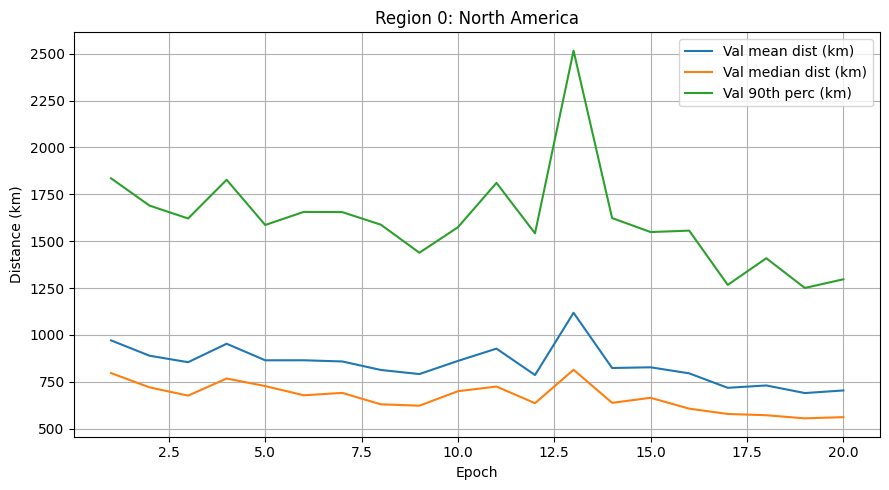

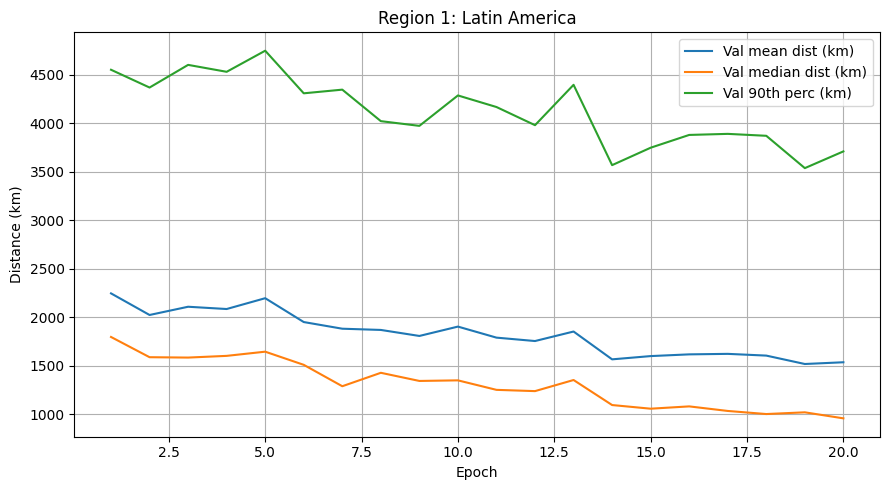

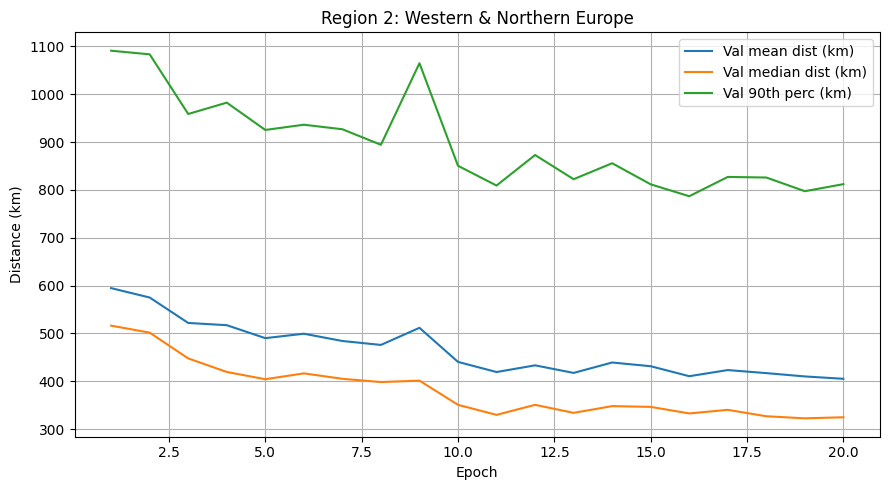

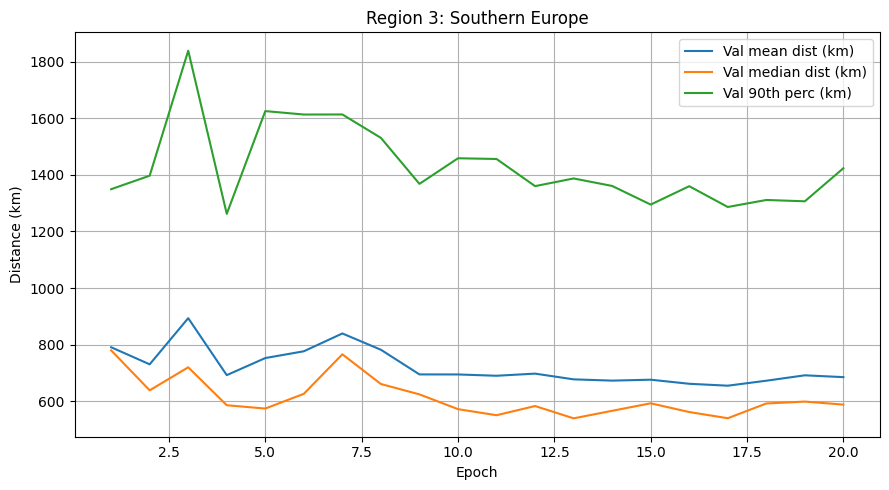

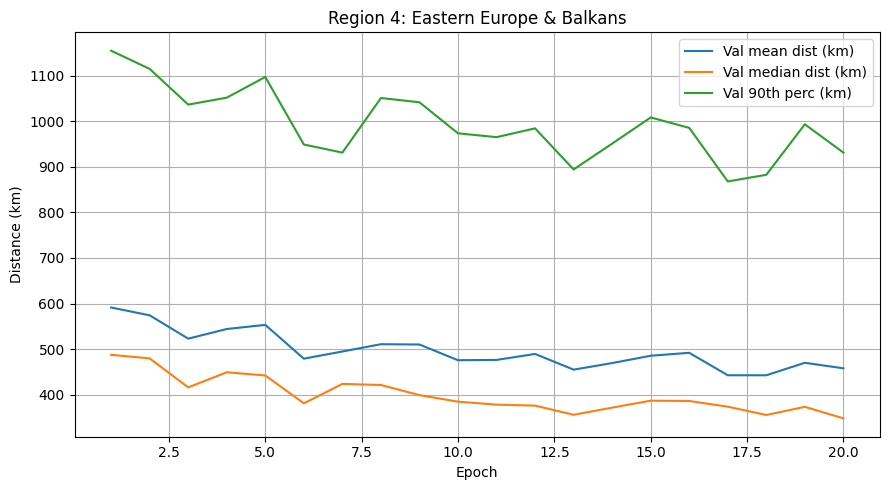

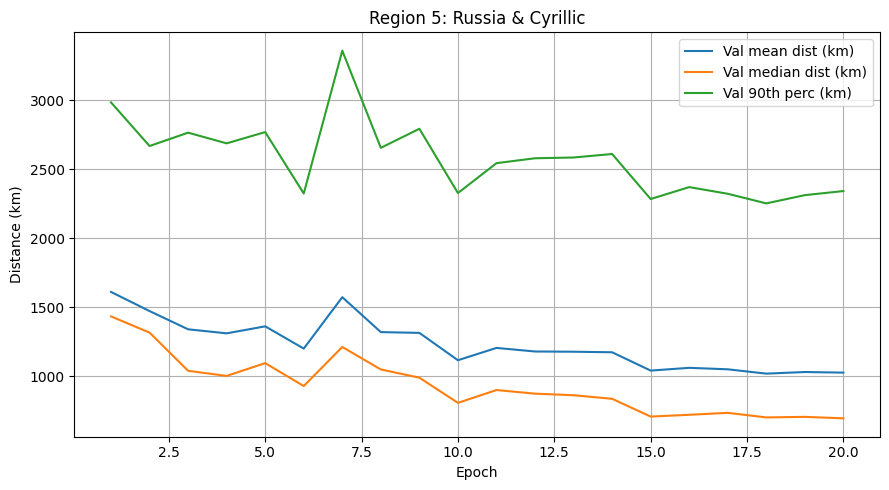

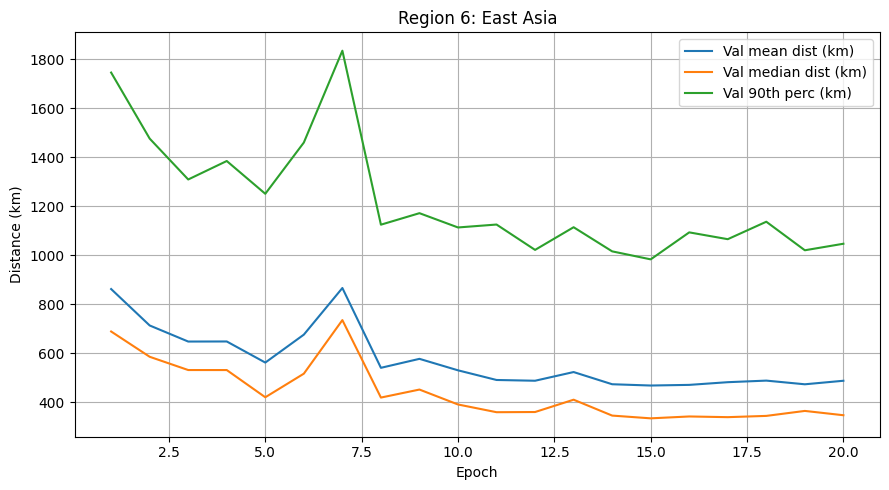

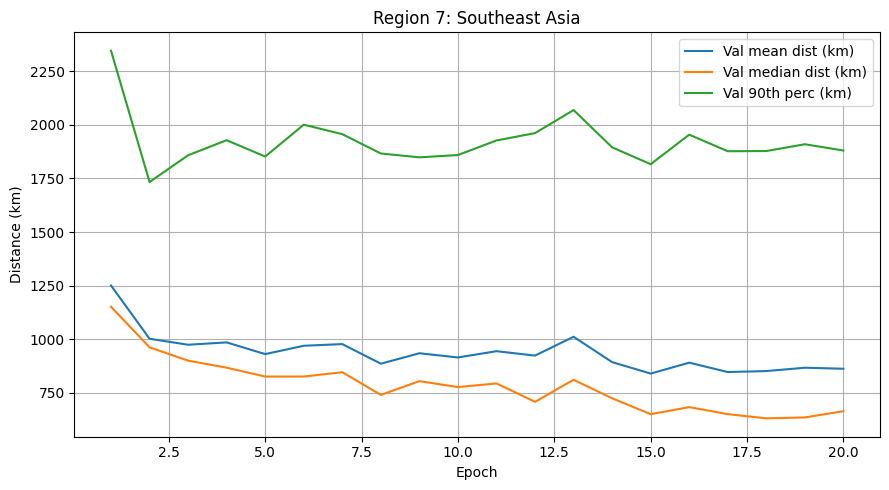

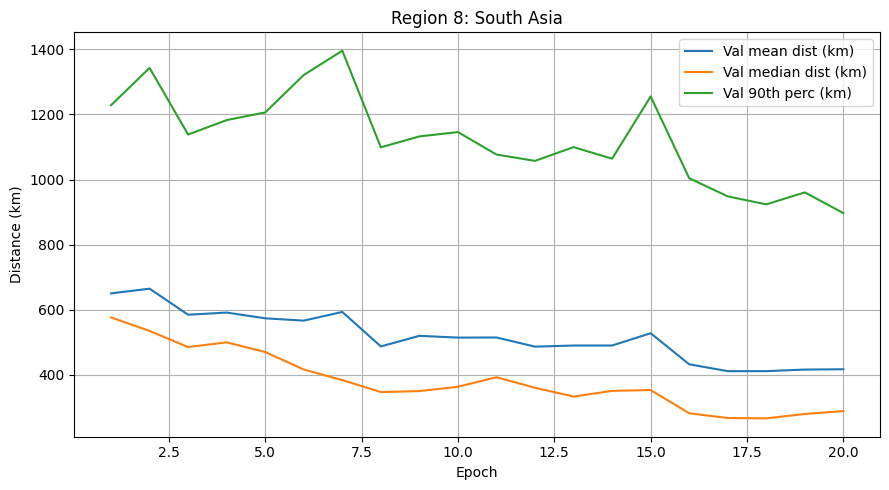

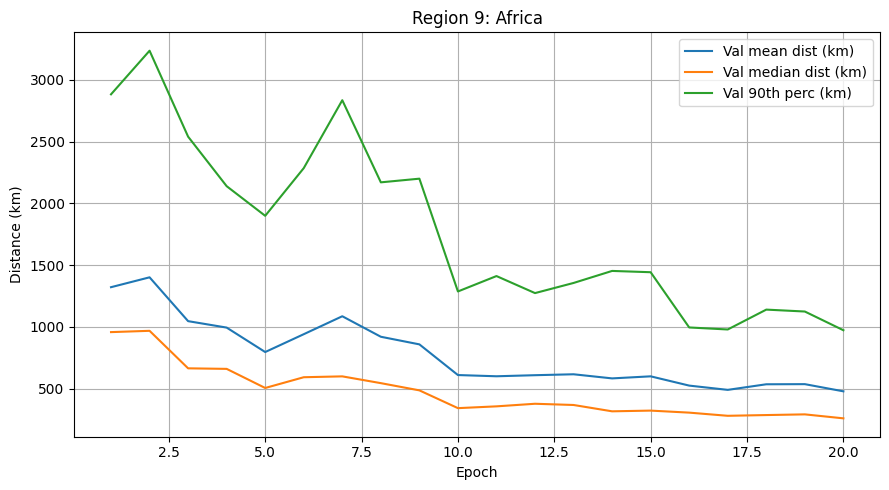

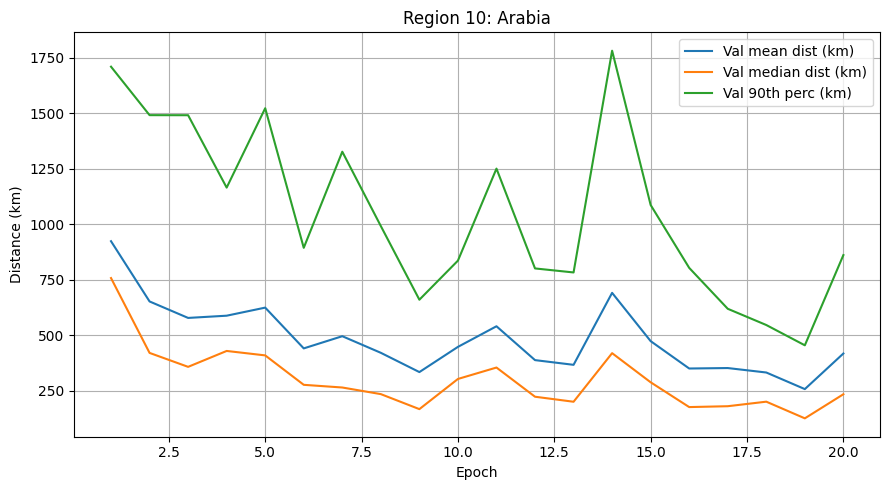

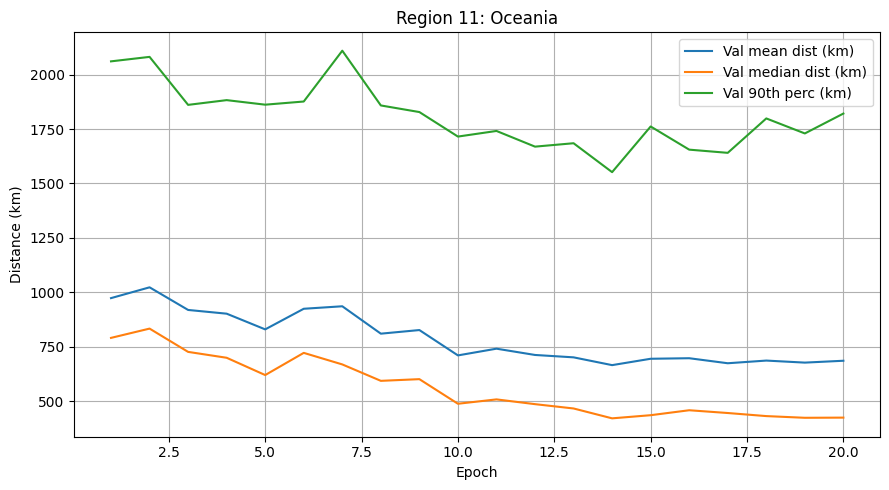

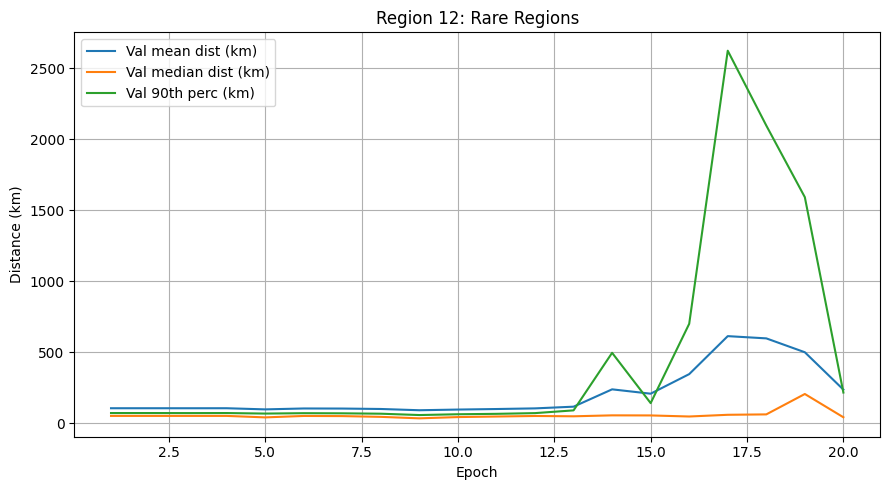

In [1]:
import matplotlib.pyplot as plt

region_names = {
    0: "North America",
    1: "Latin America",
    2: "Western & Northern Europe",
    3: "Southern Europe",
    4: "Eastern Europe & Balkans",
    5: "Russia & Cyrillic",
    6: "East Asia",
    7: "Southeast Asia",
    8: "South Asia",
    9: "Africa",
    10: "Arabia",
    11: "Oceania",
    12: "Rare Regions",
}

epochs = list(range(1, 21))

mean = {
6: [862.27, 713.47, 647.80, 648.12, 561.93, 676.05, 866.51, 540.51, 577.15, 530.28, 490.81, 487.72, 523.22, 473.42, 468.18, 470.81, 481.79, 488.24, 473.22, 487.63],
7: [1250.36, 1001.95, 974.06, 984.96, 930.40, 969.28, 977.06, 885.62, 934.35, 914.73, 944.01, 923.42, 1011.28, 892.99, 839.55, 890.43, 846.72, 851.20, 866.82, 862.11],
0: [970.59, 888.73, 854.17, 952.62, 864.34, 864.46, 858.15, 812.73, 790.91, 860.99, 926.63, 785.77, 1117.83, 823.28, 826.95, 794.69, 717.57, 730.12, 689.55, 703.47],
5: [1610.45, 1471.95, 1339.99, 1310.66, 1361.39, 1200.38, 1572.48, 1319.67, 1314.06, 1116.01, 1205.20, 1179.31, 1177.73, 1173.70, 1041.10, 1061.03, 1050.32, 1019.00, 1030.67, 1026.31],
3: [790.50, 730.07, 893.37, 691.85, 752.26, 776.25, 839.20, 781.59, 694.38, 694.26, 689.65, 697.19, 676.97, 672.44, 675.71, 661.26, 654.51, 672.12, 691.24, 684.76],
2: [594.65, 575.00, 521.82, 517.17, 490.05, 499.30, 484.10, 475.88, 511.66, 440.40, 419.18, 433.18, 417.33, 439.12, 431.35, 410.47, 423.30, 416.93, 409.98, 405.04],
8: [650.08, 664.47, 584.48, 591.11, 573.45, 566.32, 592.99, 487.00, 519.62, 514.17, 514.53, 486.38, 489.84, 489.87, 527.56, 432.13, 411.04, 411.08, 415.95, 416.86],
11: [973.82, 1023.35, 919.50, 902.38, 830.35, 924.94, 936.36, 810.65, 827.22, 710.89, 741.74, 712.90, 701.95, 666.23, 695.46, 697.93, 674.86, 687.14, 677.78, 686.34],
4: [591.25, 574.13, 522.88, 544.04, 553.14, 478.92, 494.71, 510.64, 510.02, 475.53, 476.18, 489.29, 454.87, 469.25, 485.37, 491.81, 442.51, 442.48, 469.90, 457.78],
1: [2246.12, 2023.47, 2108.36, 2084.96, 2196.41, 1950.64, 1881.99, 1869.33, 1807.36, 1903.75, 1790.01, 1754.95, 1852.92, 1566.20, 1599.79, 1617.58, 1622.73, 1604.84, 1518.26, 1536.18],
9: [1320.93, 1400.91, 1045.97, 993.80, 795.91, 940.31, 1085.64, 919.61, 857.99, 609.57, 599.66, 608.36, 615.81, 582.50, 599.16, 524.13, 489.56, 534.83, 535.88, 477.74],
10: [923.70, 652.54, 578.41, 588.43, 624.78, 441.26, 496.12, 421.36, 334.67, 448.07, 540.84, 388.49, 367.32, 691.22, 473.94, 350.74, 352.81, 332.74, 258.06, 418.28],
12: [104.37, 104.41, 104.29, 104.41, 96.31, 102.70, 102.12, 99.11, 90.26, 95.02, 98.83, 103.33, 115.36, 237.42, 206.82, 344.62, 612.04, 596.31, 498.61, 235.37],
}

median = {
6: [688.87, 585.59, 531.44, 531.34, 420.25, 516.59, 735.42, 418.97, 451.71, 390.74, 359.19, 359.94, 410.28, 345.38, 334.13, 341.78, 338.96, 344.12, 364.42, 346.84],
7: [1150.99, 961.95, 899.75, 867.02, 825.68, 825.75, 845.88, 740.11, 804.20, 776.69, 793.48, 707.86, 810.60, 724.18, 650.14, 682.98, 650.15, 630.70, 634.93, 663.97],
0: [796.07, 719.96, 675.87, 767.14, 726.89, 677.72, 690.44, 629.50, 622.19, 699.46, 724.30, 635.57, 813.88, 637.47, 664.24, 606.32, 578.10, 571.25, 554.70, 561.08],
5: [1433.35, 1316.06, 1039.49, 1002.57, 1095.13, 929.13, 1212.12, 1049.16, 989.72, 807.42, 900.13, 874.01, 862.57, 836.80, 708.14, 721.04, 735.16, 701.98, 705.99, 695.30],
3: [779.51, 638.08, 719.54, 585.39, 573.68, 625.79, 765.53, 660.41, 623.79, 571.54, 550.09, 582.59, 539.06, 565.72, 592.21, 561.34, 539.45, 591.60, 598.27, 587.66],
2: [516.19, 501.55, 447.66, 419.36, 404.13, 416.40, 405.06, 398.23, 401.19, 350.59, 329.63, 350.60, 333.83, 347.91, 346.32, 332.64, 340.10, 326.76, 322.36, 324.61],
8: [576.23, 534.58, 485.07, 499.59, 469.73, 416.26, 383.57, 346.84, 349.74, 363.06, 392.37, 359.89, 332.98, 350.51, 353.00, 281.60, 267.06, 266.04, 279.43, 288.33],
11: [791.30, 833.90, 727.01, 700.01, 620.66, 722.51, 669.47, 594.11, 601.87, 488.97, 508.97, 487.11, 467.30, 422.01, 436.42, 459.16, 446.45, 432.32, 424.53, 425.32],
4: [487.39, 479.51, 415.92, 449.10, 442.06, 380.96, 423.50, 421.15, 398.89, 384.52, 378.05, 375.86, 355.76, 371.45, 386.70, 386.02, 373.52, 355.30, 373.19, 347.94],
1: [1796.82, 1588.25, 1584.47, 1602.09, 1645.23, 1509.68, 1289.13, 1427.55, 1343.61, 1349.67, 1251.76, 1238.78, 1353.24, 1095.24, 1057.57, 1081.37, 1034.33, 1002.44, 1020.19, 958.18],
9: [957.20, 967.77, 663.98, 659.54, 504.82, 591.92, 598.87, 544.01, 485.52, 341.59, 356.09, 377.07, 367.15, 315.89, 321.68, 305.26, 279.63, 285.59, 291.18, 259.03],
10: [757.84, 420.93, 358.19, 429.74, 409.76, 277.32, 265.24, 235.43, 167.92, 303.69, 355.08, 223.74, 201.12, 419.80, 288.72, 177.13, 181.01, 201.45, 126.44, 234.90],
12: [50.39, 50.40, 50.40, 50.40, 39.96, 50.05, 49.04, 43.66, 33.23, 42.17, 46.03, 49.86, 47.61, 54.28, 53.70, 46.20, 58.21, 61.04, 204.63, 40.83],
}

p90 = {
6: [1746.54, 1476.77, 1309.80, 1385.26, 1251.37, 1460.69, 1835.78, 1125.18, 1172.18, 1113.82, 1125.77, 1022.18, 1114.75, 1016.21, 983.51, 1093.76, 1065.92, 1137.24, 1020.63, 1047.30],
7: [2345.81, 1733.19, 1858.09, 1928.32, 1852.02, 2000.71, 1956.45, 1866.27, 1848.37, 1859.11, 1927.15, 1961.31, 2068.99, 1895.11, 1816.36, 1954.09, 1876.89, 1877.75, 1909.46, 1880.17],
0: [1835.19, 1689.45, 1620.91, 1827.29, 1586.12, 1656.00, 1654.85, 1587.80, 1438.14, 1574.01, 1810.77, 1541.61, 2515.81, 1623.02, 1548.43, 1556.05, 1266.64, 1408.77, 1250.21, 1296.48],
5: [2982.79, 2667.03, 2763.68, 2686.30, 2767.89, 2323.10, 3357.04, 2653.94, 2791.85, 2326.44, 2542.81, 2578.35, 2583.91, 2609.14, 2283.24, 2369.52, 2321.28, 2251.61, 2311.30, 2340.92],
3: [1349.39, 1397.19, 1839.15, 1262.19, 1625.60, 1613.49, 1613.70, 1530.85, 1368.30, 1458.80, 1456.27, 1360.26, 1387.38, 1360.90, 1295.02, 1360.03, 1286.47, 1311.31, 1306.63, 1423.58],
2: [1091.09, 1083.52, 958.79, 982.51, 925.41, 936.34, 926.86, 894.38, 1064.93, 850.47, 809.15, 873.00, 822.40, 855.81, 811.70, 786.80, 827.16, 825.93, 797.32, 812.06],
8: [1228.07, 1342.89, 1138.12, 1182.60, 1206.09, 1321.14, 1395.77, 1098.91, 1132.39, 1145.74, 1076.70, 1057.23, 1099.49, 1064.00, 1255.11, 1003.91, 948.15, 923.61, 960.41, 896.72],
11: [2060.50, 2081.04, 1860.78, 1882.52, 1861.65, 1876.17, 2109.34, 1858.12, 1827.78, 1715.27, 1741.07, 1669.07, 1684.68, 1551.99, 1761.56, 1655.26, 1640.60, 1798.52, 1729.61, 1820.90],
4: [1154.99, 1115.06, 1036.64, 1051.94, 1097.31, 949.09, 931.31, 1051.16, 1041.77, 973.65, 965.23, 984.53, 894.33, 951.11, 1008.47, 985.66, 868.02, 882.60, 993.52, 931.27],
1: [4550.96, 4367.74, 4601.24, 4529.85, 4747.23, 4308.18, 4346.00, 4021.25, 3972.70, 4286.21, 4166.89, 3979.73, 4395.70, 3567.91, 3747.45, 3879.23, 3890.14, 3870.31, 3537.10, 3709.50],
9: [2882.57, 3235.70, 2539.80, 2138.85, 1898.89, 2284.95, 2834.96, 2169.95, 2199.62, 1286.35, 1411.09, 1273.16, 1355.22, 1452.62, 1442.15, 994.90, 978.53, 1139.42, 1123.93, 972.41],
10: [1709.21, 1491.05, 1490.75, 1164.91, 1522.17, 893.98, 1326.53, 991.75, 660.38, 836.29, 1250.47, 801.17, 783.07, 1781.09, 1086.62, 803.65, 619.55, 546.48, 455.15, 861.23],
12: [70.53, 70.53, 70.16, 70.53, 66.78, 69.55, 68.60, 65.87, 56.47, 62.04, 64.97, 70.00, 89.34, 494.55, 140.38, 698.87, 2621.81, 2094.86, 1590.51, 214.77],
}

for region_id in sorted(region_names.keys()):
    if region_id not in mean: continue
    plt.figure(figsize=(9,5))
    plt.plot(epochs, mean[region_id], label="Val mean dist (km)")
    plt.plot(epochs, median[region_id], label="Val median dist (km)")
    plt.plot(epochs, p90[region_id], label="Val 90th perc (km)")
    plt.xlabel("Epoch")
    plt.ylabel("Distance (km)")
    plt.title(f"Region {region_id}: {region_names[region_id]}")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()